# Calibrated CATE estimation and effect analysis

Loads the two calibrated per-arm pipelines saved by
`04_fit_calibrated_models.ipynb` and estimates the Conditional Average Treatment Effect

$$\mathrm{CATE}(x) = P(\text{event}\mid \text{lDAPT}, x) - P(\text{event}\mid \text{sDAPT}, x)$$

for every patient and every endpoint, then visualises the distributions.

**Sign convention** (all endpoints are *adverse* events): `CATE < 0` → lDAPT lowers the
risk (**lDAPT better**); `CATE > 0` → **sDAPT better**.

In [3]:
import os
import sys
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

PROJECT_DIR = os.path.dirname(os.path.dirname('Bachelor-Thesis'))
MODULE_DIR = os.path.join(PROJECT_DIR, 'Meta-learning')
sys.path.append(MODULE_DIR)
import pipeline_utils
from pipeline_utils import predict_proba_matrix

META_DIR = os.path.dirname(os.path.abspath(pipeline_utils.__file__))

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

import warnings
warnings.filterwarnings('ignore')

# Plot layout: target panels per row (2 or 3 keeps each panel readable).
NCOLS = 3

## Load data and the calibrated per-arm models

The feature matrix is rebuilt exactly as in the fit notebook (same leaky-column drop and
numeric selection) so the column order matches what the pipelines were fit on. The two
calibrated models are auto-detected by their `lDAPT` / `sDAPT` suffix.

In [4]:
X = pd.read_parquet(os.path.join(PROJECT_DIR, '../data/X_features.parquet'))
y_df = pd.read_parquet(os.path.join(PROJECT_DIR, '../data/y_targets.parquet'))

TARGETS = [
    'cec_barc235_335d',
    'cec_cvdeath_335d',
    'cec_mi_335d',
    'cec_stroke_335d',
    'cec_bleed_335d',
]
TARGET_LABELS = ['barc_235', 'death', 'mi', 'stroke', 'bleed']
y_df = y_df[TARGETS]

LEAKY_COLS = ['fup_other', 'fup_nitrates', 'fup_insulin']
X_num = (X.drop(columns=LEAKY_COLS, errors='ignore')
           .select_dtypes(include=[np.number]))

SAVE_DIR = os.path.join(META_DIR,'models_calibrated', 'RF')


def load_arm(suffix):
    matches = sorted(glob.glob(os.path.join(SAVE_DIR, f'*_{suffix}.joblib')))
    if not matches:
        raise FileNotFoundError(
            f'No calibrated model for {suffix} in {SAVE_DIR}; '
            'run 04_fit_calibrated_models.ipynb first.')
    return joblib.load(matches[-1]), os.path.basename(matches[-1])


pipe_l, name_l = load_arm('lDAPT')   # prolonged DAPT
pipe_s, name_s = load_arm('sDAPT')   # abbreviated DAPT
print(f'lDAPT model: {name_l}')
print(f'sDAPT model: {name_s}')
print(f'Patients: {len(X_num)}, features: {X_num.shape[1]}')

lDAPT model: RandomForest_calibrated_lDAPT.joblib
sDAPT model: RandomForest_calibrated_sDAPT.joblib
Patients: 4579, features: 60


## Estimate CATE on the full cohort

For every patient, predict the calibrated event risk under **both** arms (counterfactual
for the arm they were not assigned) and difference them. `predict_proba_matrix` returns an
`(n_patients, n_targets)` matrix, reusing each arm's own fitted imputer/scaler.

In [5]:
risk_l = predict_proba_matrix(pipe_l, X_num)   # P(event | lDAPT)
risk_s = predict_proba_matrix(pipe_s, X_num)   # P(event | sDAPT)

cate = pd.DataFrame(risk_l - risk_s, columns=TARGET_LABELS, index=X_num.index)

summary = pd.DataFrame({
    'mean_CATE': cate.mean(),
    'std_CATE': cate.std(),
    'pct_lDAPT_better': (cate < 0).mean() * 100,   # CATE<0 -> lower risk on lDAPT
    'pct_sDAPT_better': (cate > 0).mean() * 100,
})
print('CATE summary')
summary.round(4)

CATE summary


,mean_CATE,std_CATE,pct_lDAPT_better,pct_sDAPT_better
barc_235,0.039,0.032,9.522,90.478
death,0.001,0.051,39.550,60.450
mi,-0.000,0.058,78.052,21.948
stroke,0.004,0.029,7.316,92.684
bleed,0.051,0.034,6.049,93.951


## CATE distributions per target

One KDE panel per endpoint, `NCOLS` per row. Red dashed line = no effect (CATE = 0); black
line = mean CATE.

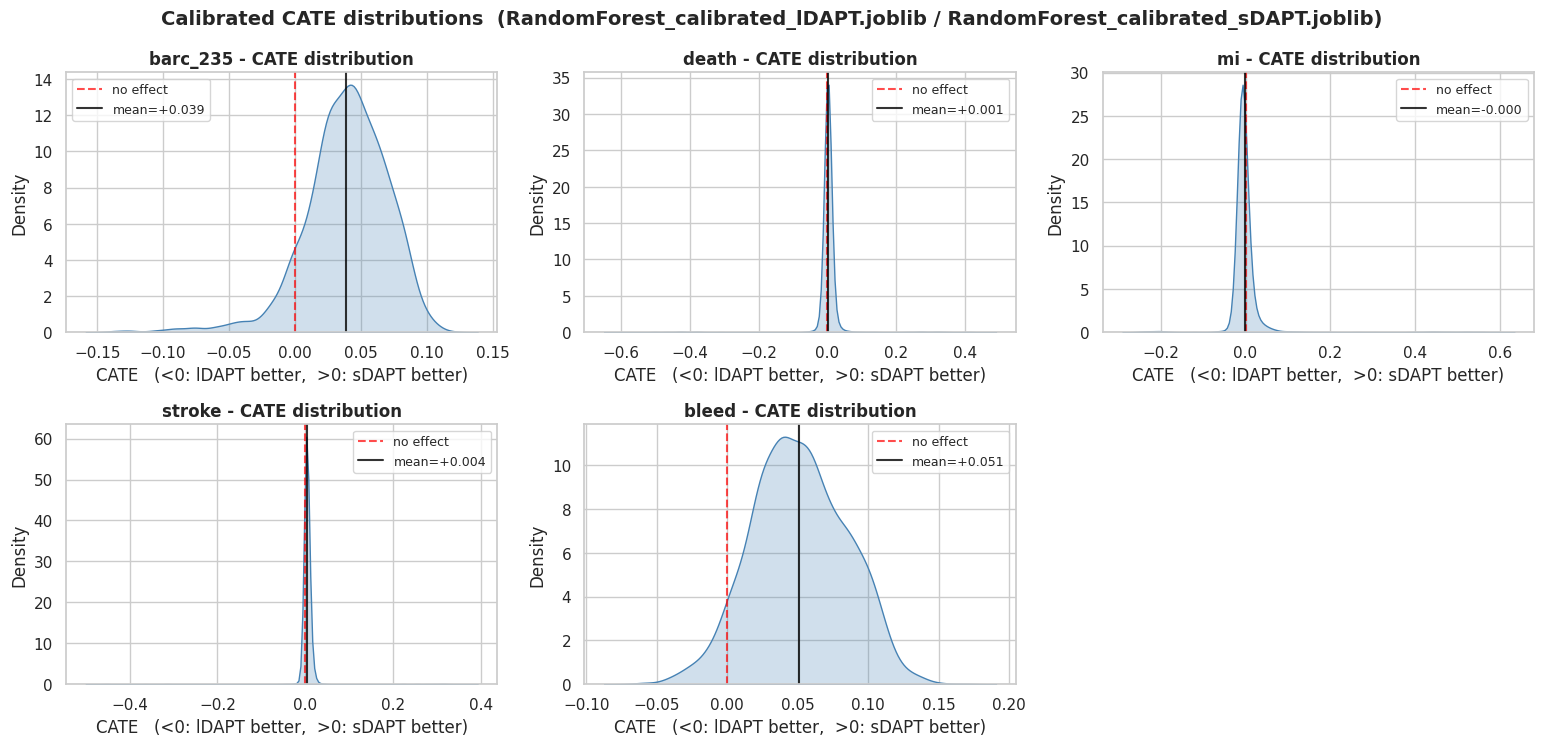

In [6]:
def target_grid(ncols, figsize_per=(5.2, 3.8)):
    # Axes grid with one cell per target, extra cells hidden.
    n = len(TARGET_LABELS)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows),
        squeeze=False,
    )
    axes = axes.ravel()
    for ax in axes[n:]:
        ax.set_visible(False)
    return fig, axes


fig, axes = target_grid(NCOLS)
for ax, label in zip(axes, TARGET_LABELS):
    sns.kdeplot(cate[label], ax=ax, fill=True, color='steelblue')
    ax.axvline(0, color='red', linestyle='--', alpha=0.7, label='no effect')
    ax.axvline(cate[label].mean(), color='black', linestyle='-', alpha=0.8,
               label=f'mean={cate[label].mean():+.3f}')
    ax.set_title(f'{label} - CATE distribution', fontweight='bold')
    ax.set_xlabel('CATE   (<0: lDAPT better,  >0: sDAPT better)')
    ax.legend(fontsize=9)
fig.suptitle(f'Calibrated CATE distributions  ({name_l} / {name_s})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Sorted CATE (uplift curves)

Patients sorted by CATE: green marks those predicted to do better on lDAPT (CATE < 0),
orange those predicted to do better on sDAPT (CATE > 0).

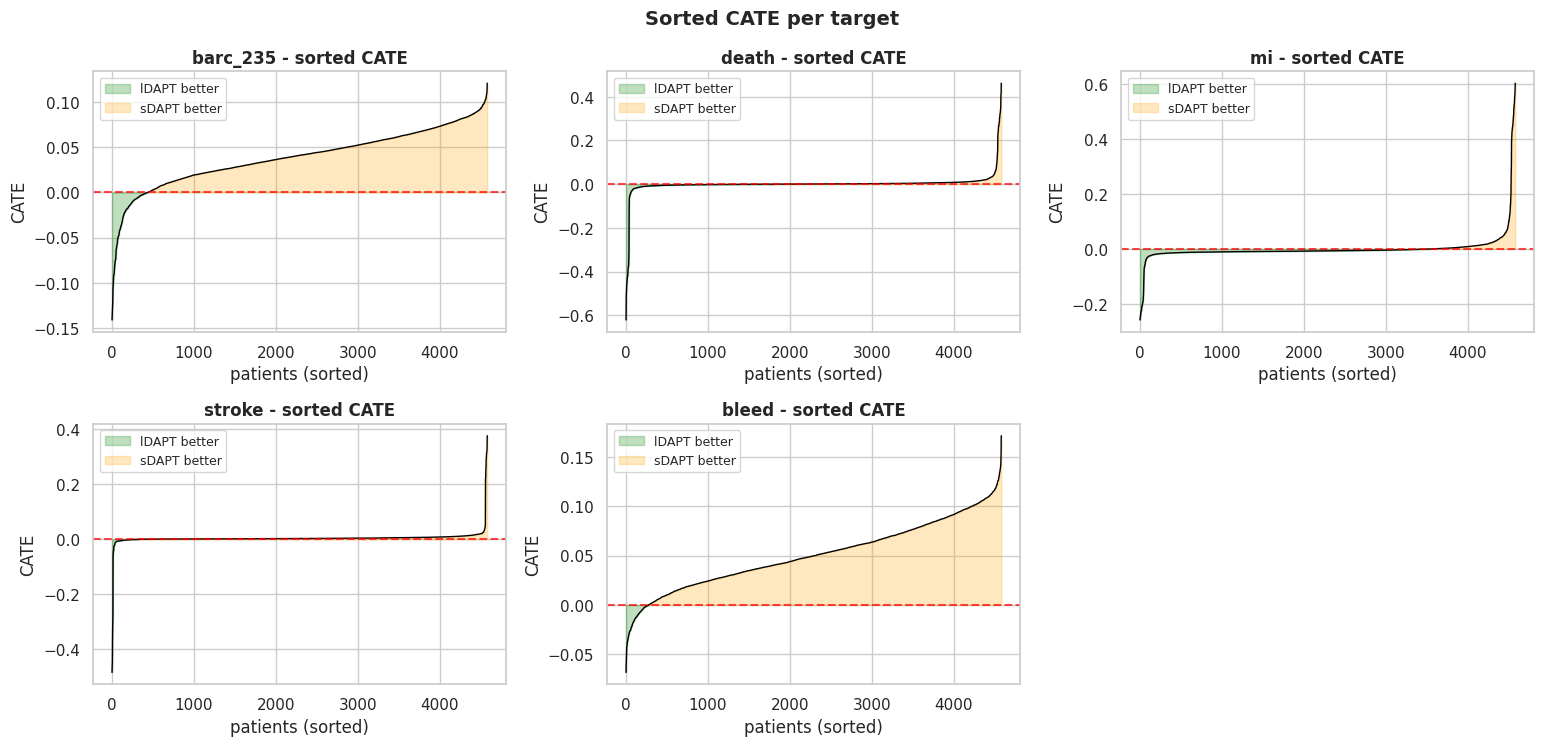

In [7]:
fig, axes = target_grid(NCOLS)
for ax, label in zip(axes, TARGET_LABELS):
    ordered = np.sort(cate[label].to_numpy())
    xs = np.arange(len(ordered))
    ax.plot(xs, ordered, linewidth=1.0, color='black')
    ax.axhline(0, color='red', linestyle='--', alpha=0.7)
    ax.fill_between(xs, ordered, 0, where=ordered < 0, color='green', alpha=0.25,
                    label='lDAPT better')
    ax.fill_between(xs, ordered, 0, where=ordered > 0, color='orange', alpha=0.25,
                    label='sDAPT better')
    ax.set_title(f'{label} - sorted CATE', fontweight='bold')
    ax.set_xlabel('patients (sorted)')
    ax.set_ylabel('CATE')
    ax.legend(fontsize=9, loc='upper left')
fig.suptitle('Sorted CATE per target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()